<a href="https://colab.research.google.com/github/swornim07/AI-and-Machine-Learning/blob/main/Worksheet2.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Student Name : Swornim Shrestha

Student Number: 2407724

Import libraries

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import OneHotEncoder
from sklearn.metrics import confusion_matrix, precision_score, recall_score, f1_score, accuracy_score

Load MNIST Dataset

In [6]:
train_df = pd.read_csv("/content/sample_data/mnist_train_small.csv")
test_df = pd.read_csv("/content/sample_data/mnist_test.csv")

# Split features and labels
X_train = train_df.iloc[:, 1:].values / 255.0
y_train = train_df.iloc[:, 0].values

X_test = test_df.iloc[:, 1:].values / 255.0
y_test = test_df.iloc[:, 0].values

One-Hot Encoding

In [7]:
encoder = OneHotEncoder(sparse_output=False)

y_train = encoder.fit_transform(y_train.reshape(-1, 1))
y_test = encoder.transform(y_test.reshape(-1, 1))

Visualize Sample Images

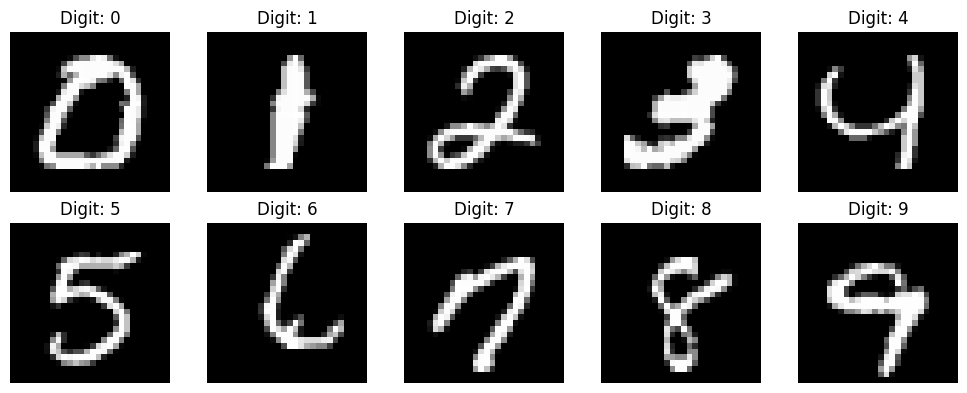

In [8]:
def plot_sample_images(X, y):
    plt.figure(figsize=(10,4))
    unique_classes = np.arange(10)

    for i, digit in enumerate(unique_classes):
        idx = np.where(np.argmax(y, axis=1) == digit)[0][0]
        image = X[idx].reshape(28, 28)

        plt.subplot(2, 5, i+1)
        plt.imshow(image, cmap='gray')
        plt.title(f"Digit: {digit}")
        plt.axis('off')

    plt.tight_layout()
    plt.show()

plot_sample_images(X_train, y_train)

Softmax Function

In [9]:
def softmax(z):
    z = z - np.max(z, axis=1, keepdims=True)
    exp_z = np.exp(z)
    return exp_z / np.sum(exp_z, axis=1, keepdims=True)

Prediction Function

In [10]:
def predict_softmax(X, W, b):
    z = np.dot(X, W) + b
    probs = softmax(z)
    return np.argmax(probs, axis=1)

Loss Function

In [11]:
def loss_softmax(y_pred, y):
    epsilon = 1e-15
    y_pred = np.clip(y_pred, epsilon, 1 - epsilon)
    return -np.mean(np.sum(y * np.log(y_pred), axis=1))

Cost Function

In [12]:
def cost_softmax(X, y, W, b):
    z = np.dot(X, W) + b
    y_pred = softmax(z)
    return loss_softmax(y_pred, y)

Gradient Function

In [13]:
def compute_gradient_softmax(X, y, W, b):
    n = X.shape[0]
    z = np.dot(X, W) + b
    y_pred = softmax(z)

    grad_W = np.dot(X.T, (y_pred - y)) / n
    grad_b = np.sum(y_pred - y, axis=0) / n

    return grad_W, grad_b

Gradient Descent

In [14]:
def gradient_descent_softmax(X, y, W, b, alpha, n_iter, show_cost=False):
    cost_history = []

    for i in range(n_iter):
        grad_W, grad_b = compute_gradient_softmax(X, y, W, b)

        W = W - alpha * grad_W
        b = b - alpha * grad_b

        cost = cost_softmax(X, y, W, b)
        cost_history.append(cost)

        if show_cost and i % 100 == 0:
            print(f"Iteration {i}, Cost: {cost:.4f}")

    return W, b, cost_history

Train Model

In [15]:
d = X_train.shape[1]
c = y_train.shape[1]

W = np.random.randn(d, c) * 0.01
b = np.zeros(c)

W_opt, b_opt, cost_history = gradient_descent_softmax(
    X_train, y_train, W, b,
    alpha=0.1,
    n_iter=1000,
    show_cost=True
)

Iteration 0, Cost: 2.2071
Iteration 100, Cost: 0.6008
Iteration 200, Cost: 0.4814
Iteration 300, Cost: 0.4316
Iteration 400, Cost: 0.4028
Iteration 500, Cost: 0.3833
Iteration 600, Cost: 0.3690
Iteration 700, Cost: 0.3579
Iteration 800, Cost: 0.3489
Iteration 900, Cost: 0.3415


Plot Cost Graph

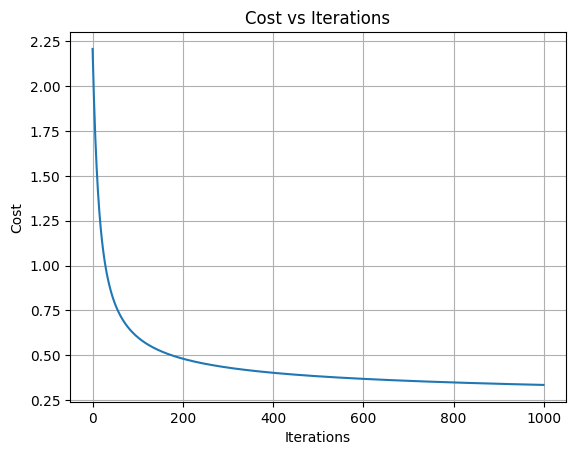

In [16]:
plt.plot(cost_history)
plt.title("Cost vs Iterations")
plt.xlabel("Iterations")
plt.ylabel("Cost")
plt.grid(True)
plt.show()

Evaluate Model

In [17]:
y_pred = predict_softmax(X_test, W_opt, b_opt)
y_true = np.argmax(y_test, axis=1)

print("Accuracy:", accuracy_score(y_true, y_pred))

Accuracy: 0.907990799079908


Confusion Matrix + Metrics

In [18]:
cm = confusion_matrix(y_true, y_pred)
precision = precision_score(y_true, y_pred, average='weighted')
recall = recall_score(y_true, y_pred, average='weighted')
f1 = f1_score(y_true, y_pred, average='weighted')

print("Confusion Matrix:\n", cm)
print("Precision:", precision)
print("Recall:", recall)
print("F1 Score:", f1)

Confusion Matrix:
 [[ 962    0    1    2    1    2    7    1    4    0]
 [   0 1103    2    4    1    2    4    1   18    0]
 [   9   10  896   17   18    0   15   18   40    9]
 [   5    0   18  907    1   33    5   16   16    9]
 [   1    3    6    0  904    0    9    1    8   50]
 [  12    3    6   42   12  743   17   10   38    9]
 [  15    3    6    2   13   11  905    1    2    0]
 [   3   18   28    5    9    0    0  925    3   36]
 [   9    9   12   29    9   23   14   15  841   13]
 [  11    8    4   11   39   12    0   25    6  893]]
Precision: 0.9077936636625659
Recall: 0.907990799079908
F1 Score: 0.9076223495204637


Question 1

Is extracting pixel values sufficient? Why or why not?

Ans: Raw pixel values alone are insufficient because they don’t capture spatial relationships, edges, or higher-level patterns. More advanced methods like CNNs are needed for better performance.

Question 2

Provide an interpretation of the output based on your understanding.

Interpretation of Linear vs Non-linear data

Ans: Logistic regression performs well on linearly separable data by using a straight decision boundary, but struggles with non-linear data since it cannot capture complex patterns, highlighting its limitation to linear relationships.

Question 3

Describe any challenges you faced while implementing the code above. Challenges faced

Ans: Some challenges included implementing a numerically stable softmax function, understanding one-hot encoding, resolving matrix dimension mismatches, tuning the learning rate and iterations, and efficiently handling a large dataset.